In [1]:
# dependencies

from Bio import AlignIO
from Bio import SeqIO
import re
import pandas as pd
import seaborn as sns
from matplotlib.colors import LogNorm


In [2]:
# results in FASTA form into dataframe

def pfam_results(results_input):
    data = {'accession': [], 'taxon': [], 'seq identifier': [], 'I Helix': []}
    with open(results_input) as fp:
        for record in SeqIO.parse(fp, "fasta"):
            seqident = re.findall(r"\|(?P<sequence_id>\w+)\|", record.id)
            accession = record.description
            taxon = re.findall(r"OX=(\d+)", record.description)
            sequence = str(record.seq)

            # attaching to dictionary
            data['seq identifier'].append(", ".join(seqident))
            data['accession'].append(accession)
            data['taxon'].append(", ".join(taxon))
            data['I Helix'].append(sequence)

    df = pd.DataFrame.from_dict(data)
    return df

In [3]:
# Converting HMM search output for pfam data to FASTA file
input = '/home/alecia/chapter3-repo/output/hmm_search_2/pfam/3/ihelixhits_e_0p001_z__T_.aln'
outfile_fasta = '/home/alecia/chapter3-repo/output/hmm_search_2/pfam/3/ihelixhits_e_0p001_z__T_.fasta'

with open(input) as infile:
    alignment = AlignIO.read(infile, 'stockholm')

SeqIO.write(alignment, outfile_fasta, 'fasta')

278757

In [4]:
pfam_r2 = pfam_results('/home/alecia/chapter3-repo/output/hmm_search_2/pfam/3/ihelixhits_e_0p001_z__T_.fasta')

In [5]:
pfam_r2

,accession,taxon,seq identifier,I Helix
0,tr|A0A182XW67|A0A182XW67_ANOST/287-321 [subseq...,30069,A0A182XW67,LDMTQV--AGQCY-S-F-F-I--A----G------FE--T-SAS--...
1,tr|A0A182XW67|A0A182XW67_ANOST/819-853 [subseq...,30069,A0A182XW67,MTLNEL--AAQVF-I-F-F-L--A----G------FE--T-SST--...
2,tr|A0A182XW67|A0A182XW67_ANOST/1316-1351 [subs...,30069,A0A182XW67,LTMNEL--AAQVF-I-F-F-V--A----G------FE--T-SST--...
3,tr|A0A182XW67|A0A182XW67_ANOST/1825-1860 [subs...,30069,A0A182XW67,LTLNEL--AAQVF-V-F-F-L--A----G------FE--T-SST--...
4,tr|A0A182XW67|A0A182XW67_ANOST/2334-2369 [subs...,30069,A0A182XW67,LTHNEL--AAQVL-I-F-F-L--A----G------FE--T-SST--...
...,...,...,...,...
278752,tr|A0A1Y2UC39|A0A1Y2UC39_9PEZI/289-316 [subseq...,1001938,A0A1Y2UC39,---------MEAI-L-F-T-V--A----G------GD--T-TST--...
278753,tr|A0A1H4E4S6|A0A1H4E4S6_9BURK/238-270 [subseq...,83784,A0A1H4E4S6,LSEVEL--LQNCI-F-I-L-N--A----G------HE--T-TTN--...
278754,tr|A0A0E4FSG9|A0A0E4FSG9_9BRAD/239-274 [subseq...,1355477,A0A0E4FSG9,LSDAEL--ISMLW-G-M-L-L--G----G------FV--T-TAA--...
278755,tr|A0A210Q976|A0A210Q976_MIZYE/289-323 [subseq...,6573,A0A210Q976,FTDNNL--TTLIG-N-V-F-S--A----G------TE--T-TAT--...


In [17]:
# If sequence in I_Helix y, take the acid alcohol - if not, take the acid alcohol in I Helix x

result_data = []

for index, row in pfam_r2.iterrows():
    acid = row['I Helix'][36]
    alc = row['I Helix'][39]

    # Append a dictionary with relevant information to the result_data list
    result_data.append({
        'accession': row['accession'],
        'sequence': row['I Helix'],
        'seq identifier': row['seq identifier'],
        'acid': acid,
        'alc': alc,
        'taxon': row['taxon'],
    })


# Create a DataFrame from the result_data list
result_df = pd.DataFrame(result_data)


In [18]:
result_df

,accession,sequence,seq identifier,acid,alc,taxon
0,tr|A0A182XW67|A0A182XW67_ANOST/287-321 [subseq...,LDMTQV--AGQCY-S-F-F-I--A----G------FE--T-SAS--...,A0A182XW67,E,T,30069
1,tr|A0A182XW67|A0A182XW67_ANOST/819-853 [subseq...,MTLNEL--AAQVF-I-F-F-L--A----G------FE--T-SST--...,A0A182XW67,E,T,30069
2,tr|A0A182XW67|A0A182XW67_ANOST/1316-1351 [subs...,LTMNEL--AAQVF-I-F-F-V--A----G------FE--T-SST--...,A0A182XW67,E,T,30069
3,tr|A0A182XW67|A0A182XW67_ANOST/1825-1860 [subs...,LTLNEL--AAQVF-V-F-F-L--A----G------FE--T-SST--...,A0A182XW67,E,T,30069
4,tr|A0A182XW67|A0A182XW67_ANOST/2334-2369 [subs...,LTHNEL--AAQVL-I-F-F-L--A----G------FE--T-SST--...,A0A182XW67,E,T,30069
...,...,...,...,...,...,...
278752,tr|A0A1Y2UC39|A0A1Y2UC39_9PEZI/289-316 [subseq...,---------MEAI-L-F-T-V--A----G------GD--T-TST--...,A0A1Y2UC39,D,T,1001938
278753,tr|A0A1H4E4S6|A0A1H4E4S6_9BURK/238-270 [subseq...,LSEVEL--LQNCI-F-I-L-N--A----G------HE--T-TTN--...,A0A1H4E4S6,E,T,83784
278754,tr|A0A0E4FSG9|A0A0E4FSG9_9BRAD/239-274 [subseq...,LSDAEL--ISMLW-G-M-L-L--G----G------FV--T-TAA--...,A0A0E4FSG9,V,T,1355477
278755,tr|A0A210Q976|A0A210Q976_MIZYE/289-323 [subseq...,FTDNNL--TTLIG-N-V-F-S--A----G------TE--T-TAT--...,A0A210Q976,E,T,6573


In [ ]:
acidalc = result_df.groupby('acid').alc.value_counts()
acidalc.to_csv('pfam_r2_allacidalc.csv')


In [20]:
count = pd.read_csv('/home/alecia/chapter3-repo/analysis/pfam_heatmap/pfam_r2_allacidalc.csv')
count

,acid,alc,count
0,-,T,1
1,A,T,1651
2,A,S,49
3,A,A,10
4,A,N,9
...,...,...,...
127,Y,T,140
128,Y,S,10
129,Y,N,8
130,Y,P,1


In [21]:
heatmap_data = (count.pivot(index='alc', columns='acid', values='count')
                .fillna(0)
)
heatmap_orderedAA = (heatmap_data.reindex(columns=['E','D','H','K','R','G','P','C','A','I','V','L','M','F','Y','W','Q','S','N','T'])
                     .reindex(['E','D','H','K','R','G','P','C','A','I','V','L','M','F','Y','W','Q','S','N','T'])
                     .fillna(0)
)
heatmap_orderedAA

acid,E,D,H,K,R,G,P,C,A,I,V,L,M,F,Y,W,Q,S,N,T
alc,,,,,,,,,,,,,,,,,,,,
E,17.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
D,2.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
H,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
K,18.0,8.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
R,4.0,10.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
G,96.0,118.0,2.0,0.0,0.0,11.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,9.0,3.0
P,915.0,491.0,7.0,5.0,1.0,17.0,0.0,0.0,3.0,4.0,6.0,1.0,1.0,0.0,1.0,0.0,11.0,11.0,7.0,3.0
C,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A,997.0,2018.0,27.0,0.0,0.0,10.0,3.0,0.0,10.0,2.0,19.0,3.0,1.0,2.0,0.0,0.0,5.0,10.0,39.0,8.0


[Text(0.5, 23.52222222222222, 'Acid'),
 Text(50.722222222222214, 0.5, 'Alcohol')]

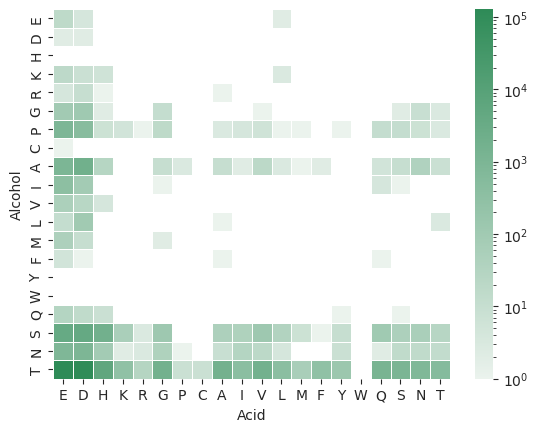

In [23]:
cmap = sns.light_palette('seagreen', as_cmap=True)
sns.set_style(style='ticks')
sns.axes_style({'font.sans-serif': 'Arial'})

heatmap = sns.heatmap(
    heatmap_orderedAA,
    norm=LogNorm(),
    linecolor='white',
    linewidths=0.5,
    cmap=cmap
    )

heatmap.set(xlabel="Acid", ylabel="Alcohol")
